In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from matplotlib.gridspec import GridSpec

from hbn.constants import Defaults  
from hbn.visualization import make_tables, visualize as vis, utils

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
vis.plotting_style()

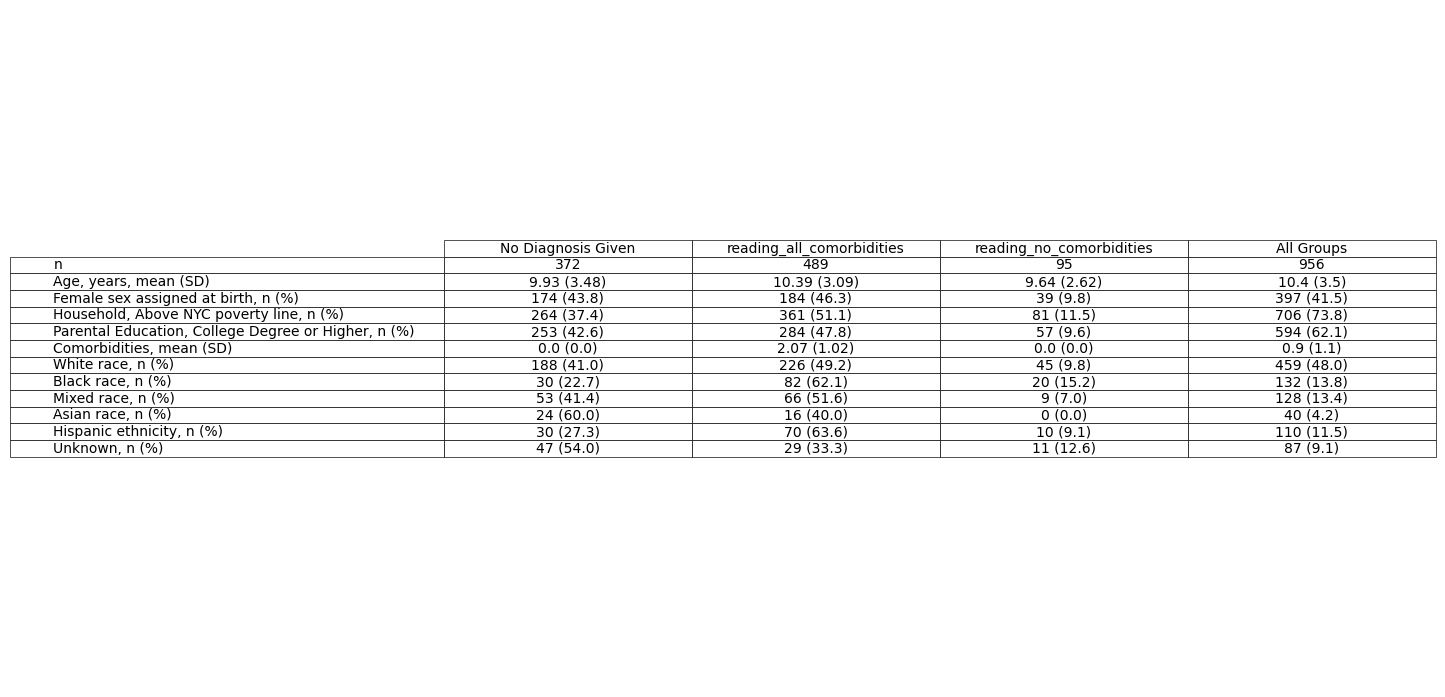

In [9]:
make_tables.make_table_1()

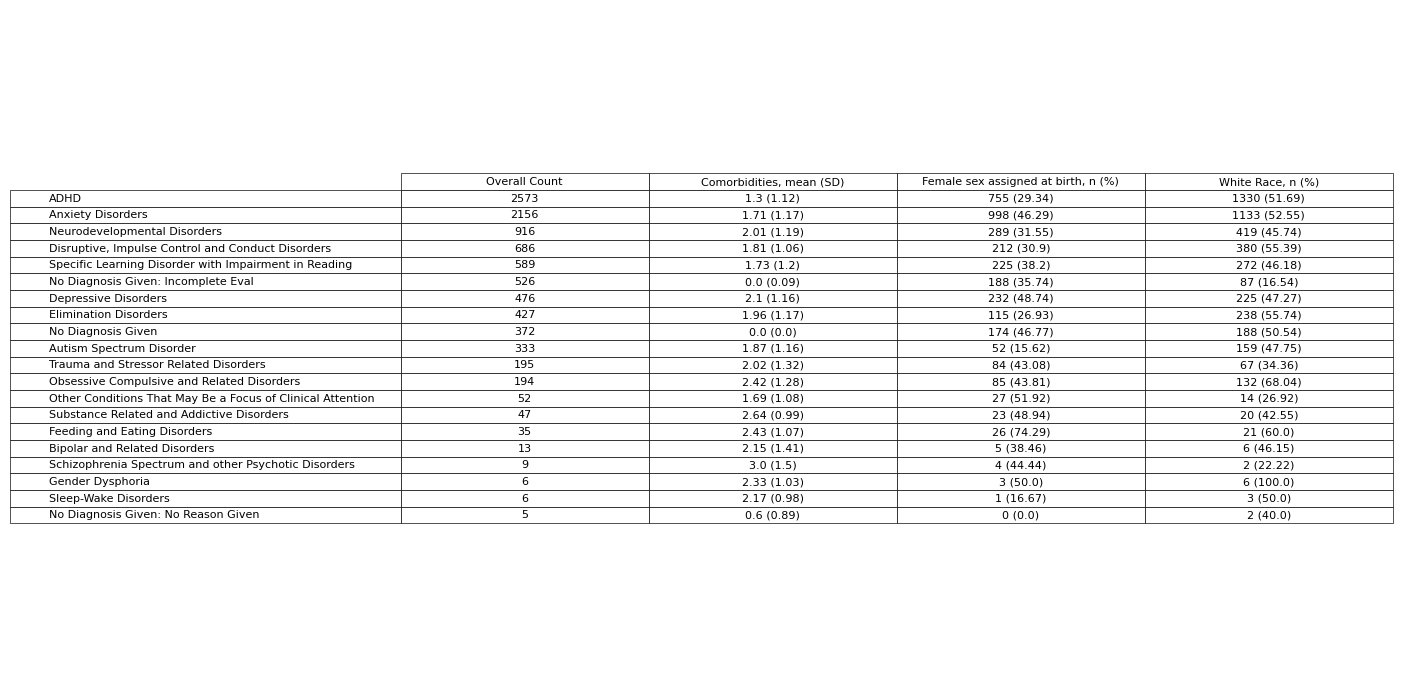

In [10]:
make_tables.make_table_2()

## Proportion of diagnosis across ages

what do we want to know here? 

is there a difference in the ratio of males to females across age? might give us some insight into when females are being diagnosed with reading impairment 

how do we calculate this? for the different groups: reading (no comorb.), reading (all comorbid), no diagnosis OR do reading diagnosis / no reading diagnosis: calculate % of women with reading impairment and plot that number over time.

In [122]:
df1['DX_Reading'].value_counts()

adhd_no_reading              2103
other_diagnoses              1241
reading_all_comorbidities     462
No Diagnosis Given            352
reading_no_comorbidities       93
Name: DX_Reading, dtype: int64

Text(0.5, 1.0, 'Reading (All comorbidities) vs. ADHD (no reading)')

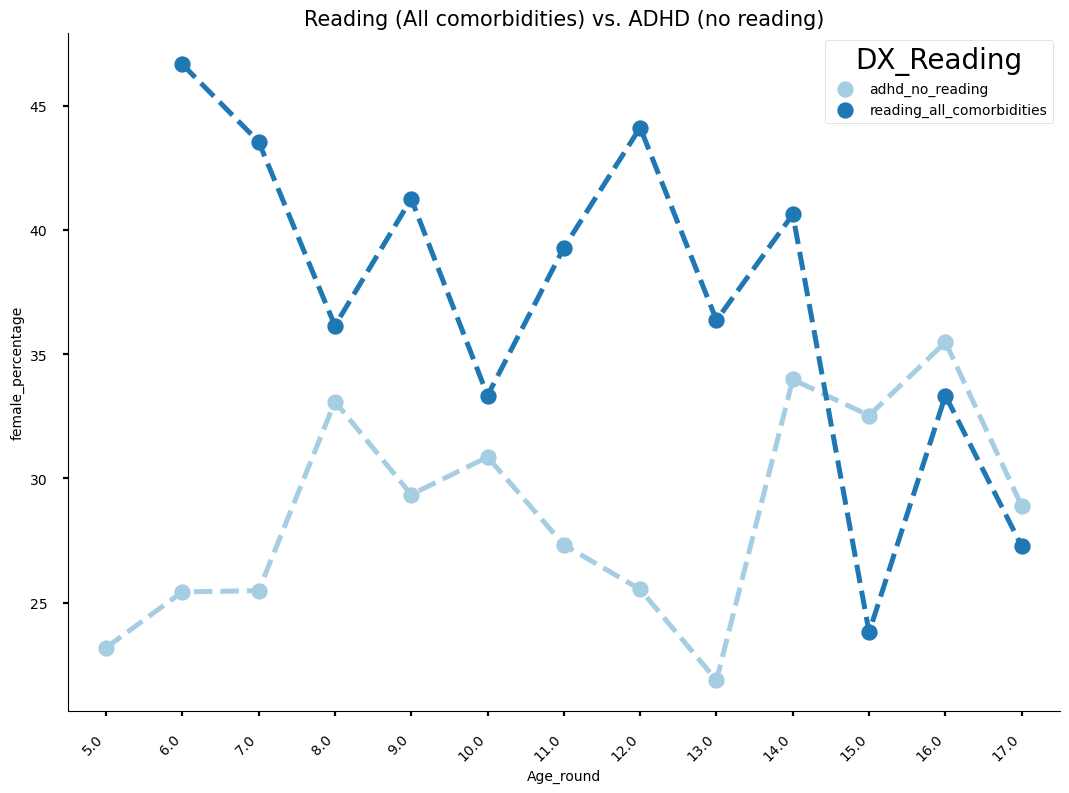

In [3]:

def calculate_sex_percentage(df, groupby_cols=['Age_round', 'reading', 'Race']):
  """Calculates the percentage of females for each combination of age and diagnosis.

  Args:
    df: The pandas DataFrame containing the data.

  Returns:
    A pandas DataFrame with additional column 'female_percentage'.
  """

  # Create a groupby object based on 'age' and 'diagnosis'
  grouped_df = df.groupby(groupby_cols)

  # Calculate the number of females in each group
  female_counts = grouped_df['Sex'].apply(lambda x: (x == 'female').sum())
  male_counts = grouped_df['Sex'].apply(lambda x: (x == 'male').sum())

  # Calculate the total count in each group
  total_counts = grouped_df['Sex'].count()

  # Calculate the female percentage
  female_percentage = (female_counts / total_counts) * 100
  male_percentage = (male_counts / total_counts) * 100

  # Add the female percentage as a new column to the original DataFrame
  df['female_percentage'] = df.set_index(groupby_cols).index.map(female_percentage)
  df['male_percentage'] = df.set_index(groupby_cols).index.map(male_percentage)

  return df

# load data
df = pd.read_csv(os.path.join(Defaults.INTERIM_FEATURES_DIR, 'participant_train_test.csv'))
df.rename(columns={'PreInt_Demos_Fam,Child_Race_cat':'Race'}, inplace=True)

# filter data
df1 = df.loc[df['Age_round']<=17].groupby('Identifiers').first().reset_index()

# calculate female percentage
df_filter = calculate_sex_percentage(df1, groupby_cols=['Age_round', 'DX_Reading'])

# plot female percentage across age and diagnosis
data = df_filter[df_filter['DX_Reading'].isin(['reading_all_comorbidities', 'adhd_no_reading'])]
sns.pointplot(x='Age_round', y='female_percentage', data=data, hue='DX_Reading', linestyles='--')
plt.xticks(rotation=45, ha='right'); 
plt.title('Reading (All comorbidities) vs. ADHD (no reading)')



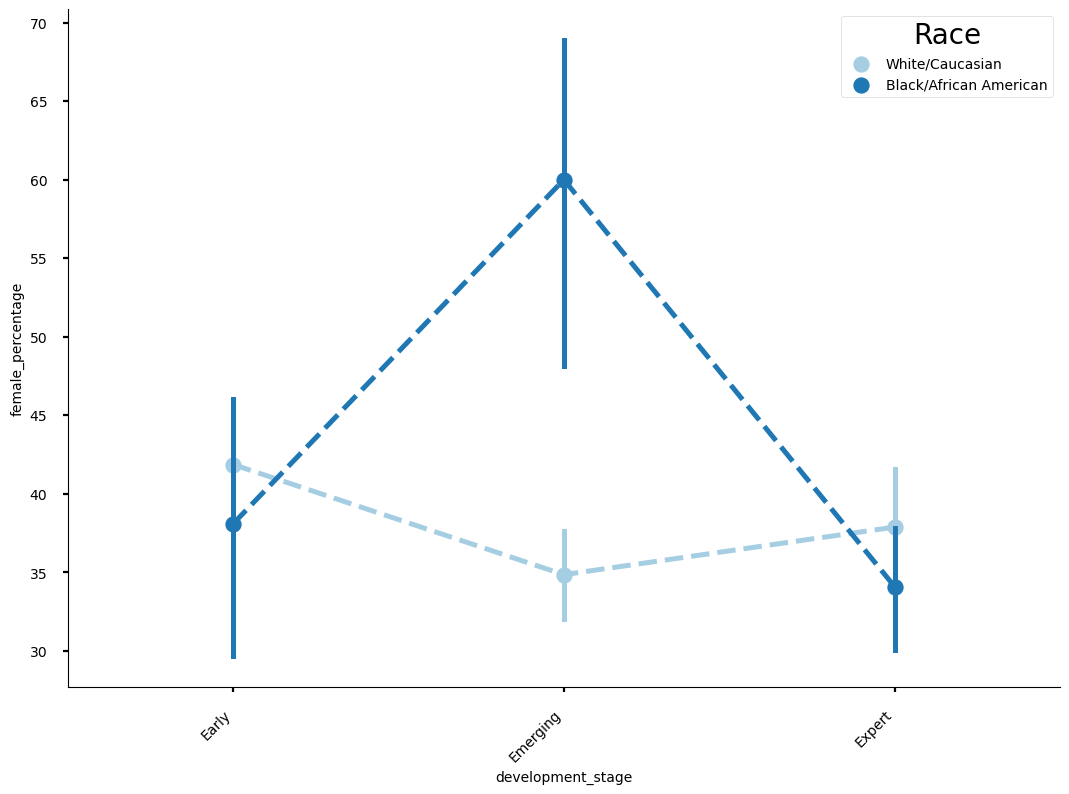

In [8]:
df1.loc[df1['Age_round'].isin([6,7,8]), 'development_stage'] = 'Early'
df1.loc[df1['Age_round'].isin([9,10]), 'development_stage'] = 'Emerging'
df1.loc[df1['Age_round'].isin([11,12,13,14,15,16,17,18]), 'development_stage'] = 'Expert'

# calculate female percentage
df_filter = calculate_sex_percentage(df1, groupby_cols=['Age_round', 'DX_Reading', 'Race'])

# plot female percentage across age and diagnosis
data = df_filter[(df_filter['DX_Reading'].isin(['reading_all_comorbidities'])) & 
                 (df_filter['Race'].isin(['White/Caucasian', 'Black/African American']))]

sns.pointplot(x='development_stage', y='female_percentage', data=data.sort_values(by='development_stage'), hue='Race', linestyles='--')
plt.xticks(rotation=45, ha='right'); 

### ADHD plots

<Axes: xlabel='development_stage', ylabel='female_percentage'>

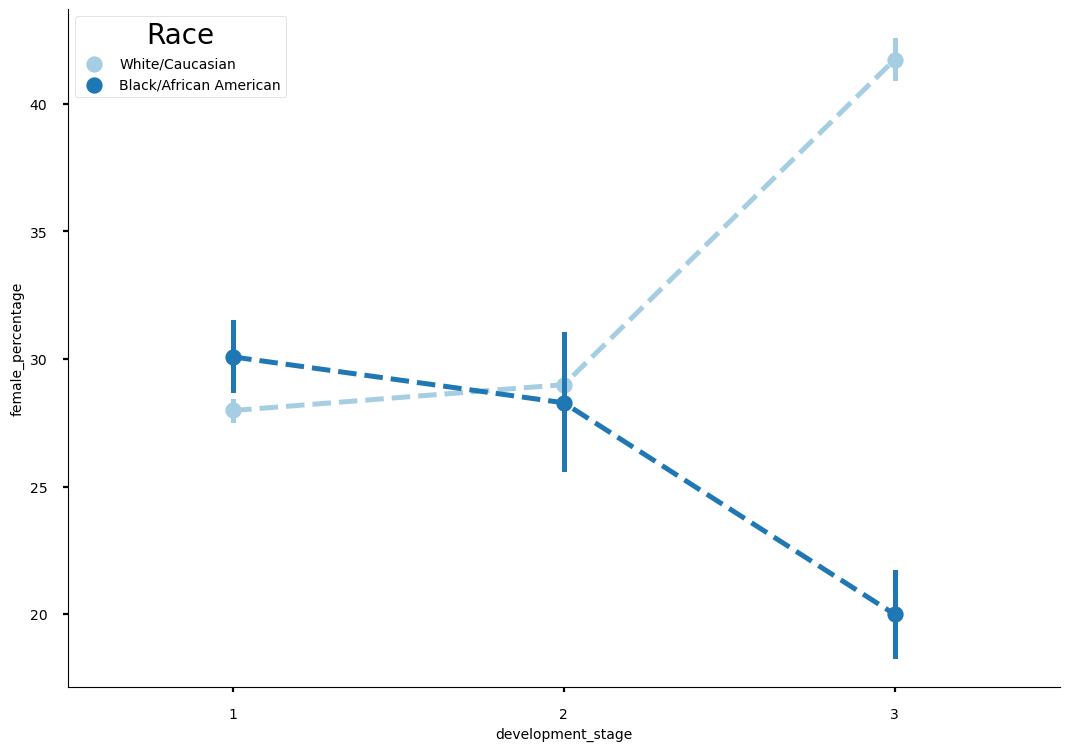

In [11]:
df1.loc[df1['Age_round'].isin([5,6,7,8,9]), 'development_stage'] = 1
df1.loc[df1['Age_round'].isin([10,11,12,13]), 'development_stage'] = 2
df1.loc[df1['Age_round'].isin([14,15,16,17,18]), 'development_stage'] = 3

df = calculate_sex_percentage(df1, groupby_cols=['Age_round', 'DX_ADHD', 'Race'])

df_filter = df[(df['DX_ADHD'].isin(['adhd_all_comorbidities'])) 
               & (df['Race'].isin([ 'White/Caucasian', 'Black/African American']))]

sns.pointplot(x='development_stage', y='female_percentage', data=df_filter.sort_values(by='development_stage'), hue='Race', linestyles='--')

<Axes: xlabel='development_stage', ylabel='female_percentage'>

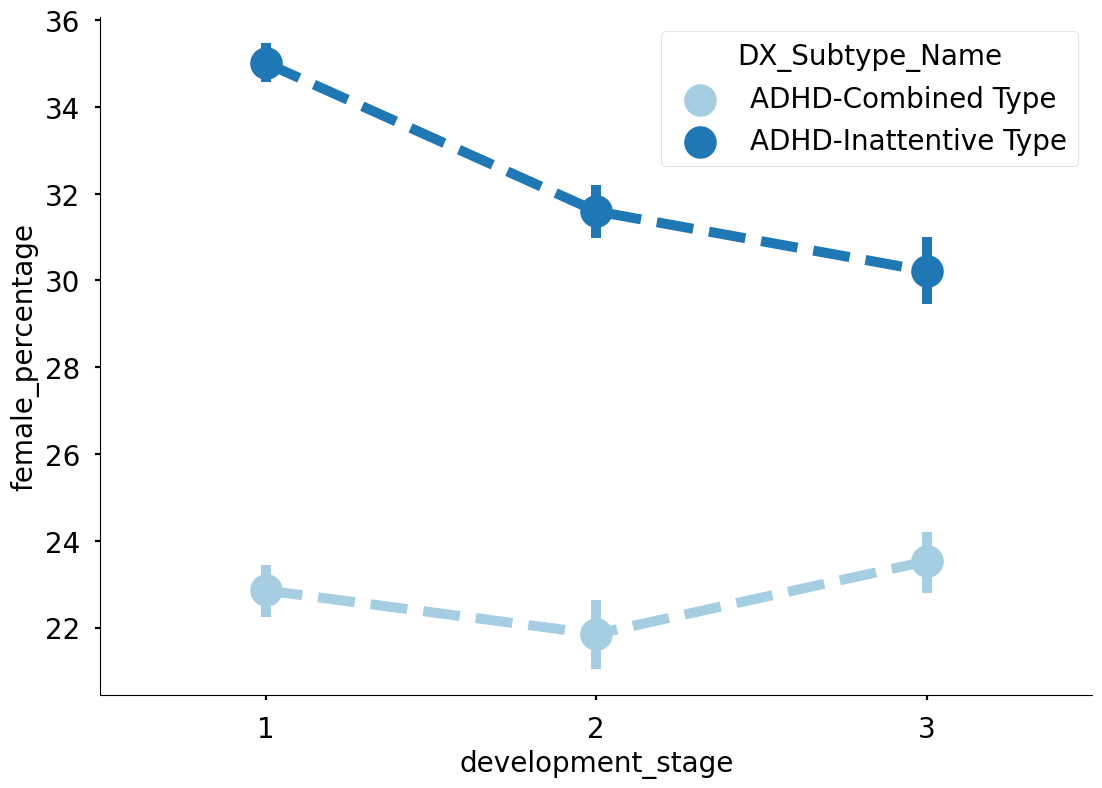

In [104]:
df1.loc[df1['Age_round'].isin([5,6,7,8,9]), 'development_stage'] = 1
df1.loc[df1['Age_round'].isin([10,11,12,13]), 'development_stage'] = 2
df1.loc[df1['Age_round'].isin([14,15,16,17,18]), 'development_stage'] = 3

df = calculate_sex_percentage(df1, groupby_cols=['Age_round', 'DX_Subtype_Name'])

df_filter = df[(df['DX_Subtype_Name'].isin(['ADHD-Combined Type', 'ADHD-Inattentive Type'])) 
               ]

sns.pointplot(x='development_stage', y='female_percentage', data=df_filter.sort_values(by='development_stage'), hue='DX_Subtype_Name', linestyles='--')

<Axes: xlabel='development_stage', ylabel='female_percentage'>

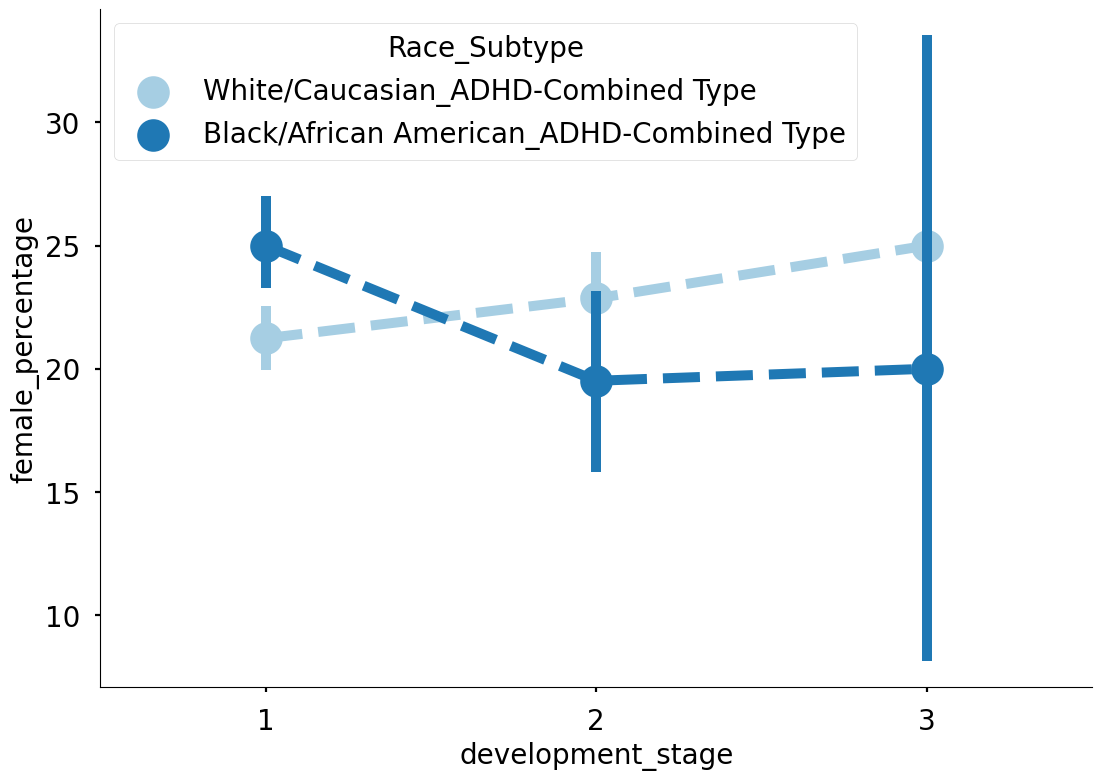

In [108]:
df1.loc[df1['Age_round'].isin([5,6,7,8,9]), 'development_stage'] = 1
df1.loc[df1['Age_round'].isin([10,11,12,13]), 'development_stage'] = 2
df1.loc[df1['Age_round'].isin([14,15,16,17,18]), 'development_stage'] = 3

df1['Race_Subtype'] = df1['Race'] + '_' + df1['DX_Subtype_Name']

df = calculate_sex_percentage(df1, groupby_cols=['Age_round', 'Race_Subtype'])

df_filter = df[(df['Race_Subtype'].isin(['Black/African American_ADHD-Combined Type', 
                                        'White/Caucasian_ADHD-Combined Type',])) 
                                        ]

sns.pointplot(x='development_stage', y='female_percentage', data=df_filter.sort_values(by='development_stage'), hue='Race_Subtype', linestyles='--')

<Axes: xlabel='development_stage', ylabel='female_percentage'>

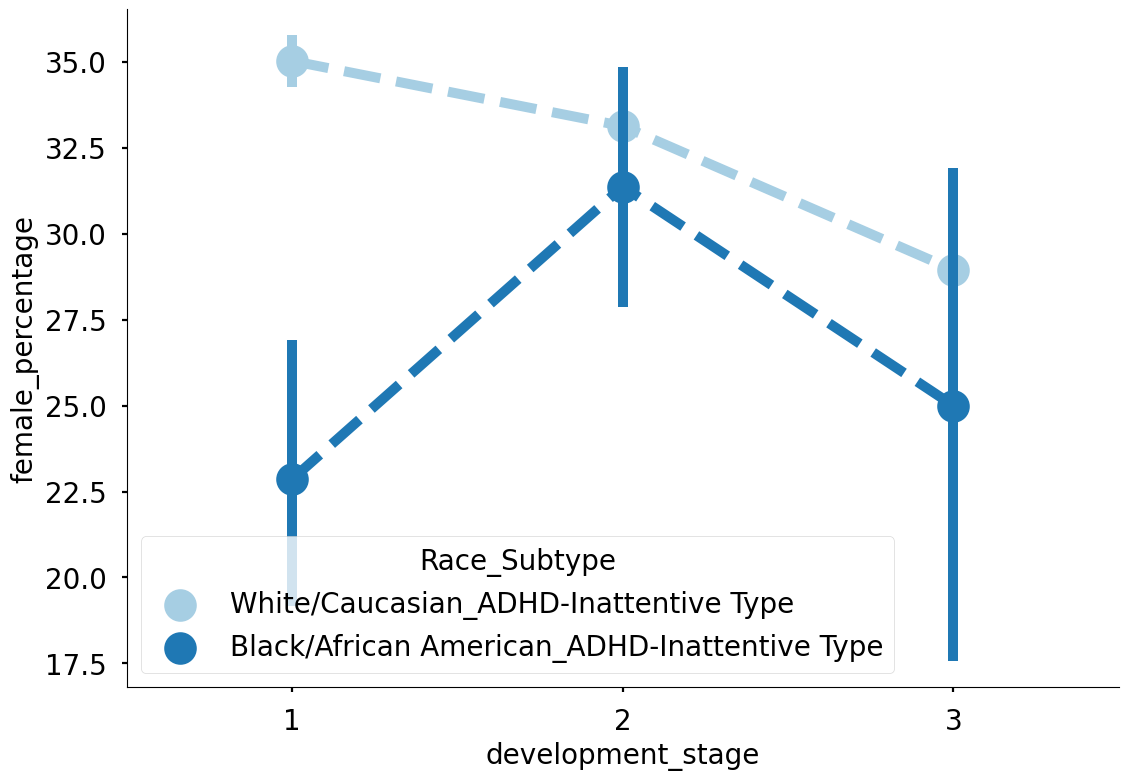

In [109]:
df1.loc[df1['Age_round'].isin([5,6,7,8,9]), 'development_stage'] = 1
df1.loc[df1['Age_round'].isin([10,11,12,13]), 'development_stage'] = 2
df1.loc[df1['Age_round'].isin([14,15,16,17,18]), 'development_stage'] = 3

df1['Race_Subtype'] = df1['Race'] + '_' + df1['DX_Subtype_Name']

df = calculate_sex_percentage(df1, groupby_cols=['Age_round', 'Race_Subtype'])

df_filter = df[(df['Race_Subtype'].isin(['Black/African American_ADHD-Inattentive Type',
                                        'White/Caucasian_ADHD-Inattentive Type'])) 
                                        ]

sns.pointplot(x='development_stage', y='female_percentage', data=df_filter.sort_values(by='development_stage'), hue='Race_Subtype', linestyles='--')